<a href="https://colab.research.google.com/github/Hhasan04/MLHomeWorks/blob/MLProject/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [135]:
# Cell 1: Install and Import Libraries
!pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import roc_curve, auc, precision_recall_curve, classification_report, confusion_matrix
from scipy.stats import multivariate_normal

print("Libraries imported successfully!")

Libraries imported successfully!


In [154]:
# Cell 2: Load Dataset
from google.colab import files
#uploaded = files.upload()

# Get the uploaded filename
#filename = list(uploaded.keys())[0]
df = pd.read_csv("/content/transactions.csv")

print(f"Dataset shape: {df.shape}")
print("\nFraud distribution:")
print(df['is_fraud'].value_counts())
print(f"Fraud percentage: {df['is_fraud'].mean()*100:.2f}%")


Dataset shape: (299695, 17)

Fraud distribution:
is_fraud
0    293083
1      6612
Name: count, dtype: int64
Fraud percentage: 2.21%


In [155]:
# Cell 3: Feature Engineering - Time Features
# Convert transaction_time to datetime and extract features
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

# Extract time-based features
df['hour'] = df['transaction_time'].dt.hour
df['day_of_week'] = df['transaction_time'].dt.dayofweek
df['day_of_month'] = df['transaction_time'].dt.day
df['month'] = df['transaction_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Create cyclical features for hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Create cyclical features for day of week
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print("Time features created:")
print(df[['transaction_time', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos']].head())
print(f"Dataset shape: {df.shape}")


Time features created:
           transaction_time  hour  day_of_week  is_weekend  hour_sin  \
0 2024-01-06 04:09:39+00:00     4            5           1  0.866025   
1 2024-01-09 20:13:47+00:00    20            1           0 -0.866025   
2 2024-01-12 06:20:11+00:00     6            4           0  1.000000   
3 2024-01-15 17:00:04+00:00    17            0           0 -0.965926   
4 2024-01-17 01:27:31+00:00     1            2           0  0.258819   

       hour_cos  
0  5.000000e-01  
1  5.000000e-01  
2  6.123234e-17  
3 -2.588190e-01  
4  9.659258e-01  
Dataset shape: (299695, 26)


In [156]:
# Cell 4: Preprocessing - Drop Identifiers and Original Time Column
columns_to_drop = ['transaction_id', 'user_id', 'transaction_time']
df_processed = df.drop(columns=columns_to_drop)

print(f"Columns after dropping identifiers: {df_processed.shape[1]}")
print(f"Remaining columns: {list(df_processed.columns)}")



Columns after dropping identifiers: 23
Remaining columns: ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'is_fraud', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


In [157]:
# Cell 5: Separate Labels from Features
y_true = df_processed['is_fraud'].values
X = df_processed.drop(columns=['is_fraud'])

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y_true.shape}")
print(f"Number of fraud cases: {y_true.sum()}")
print(f"Number of normal cases: {(y_true == 0).sum()}")
print(f"Feature columns: {list(X.columns)}")


Features shape: (299695, 22)
Labels shape: (299695,)
Number of fraud cases: 6612
Number of normal cases: 293083
Feature columns: ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


In [158]:
# Cell 6: Identify Column Types
numeric_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user',
                'amount', 'shipping_distance_km', 'hour', 'day_of_week',
                'day_of_month', 'month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

binary_cols = ['promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'is_weekend']

categorical_cols = ['country', 'bin_country', 'channel', 'merchant_category']

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nBinary columns ({len(binary_cols)}): {binary_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")


Numeric columns (13): ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'shipping_distance_km', 'hour', 'day_of_week', 'day_of_month', 'month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

Binary columns (5): ['promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'is_weekend']

Categorical columns (4): ['country', 'bin_country', 'channel', 'merchant_category']


In [159]:
# Cell 7: Encode Categorical Variables
X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {X_encoded[col].nunique()} unique values")

print("\nEncoded dataset shape:", X_encoded.shape)


Encoded country: 10 unique values
Encoded bin_country: 10 unique values
Encoded channel: 2 unique values
Encoded merchant_category: 5 unique values

Encoded dataset shape: (299695, 22)


In [143]:
# Cell 8: Scale Numeric Features
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

print("Features scaled successfully!")
print(f"Scaled data shape: {X_scaled.shape}")

Features scaled successfully!
Scaled data shape: (299695, 22)


In [160]:
# Cell 9: CRITICAL - Train/Test Split (Time-Based)
print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)

# Sort by original index to maintain temporal order
# If you have the original timestamp, sort by that for true temporal split
# For now, we'll use stratified random split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_true,
    test_size=0.3,
    random_state=42,
    stratify=y_true  # Maintain fraud ratio in both sets
)

print(f"\nTotal samples: {len(X_scaled)}")
print(f"\nTraining set: {len(X_train)} samples")
print(f"  - Normal: {(y_train == 0).sum()}")
print(f"  - Fraud: {y_train.sum()}")
print(f"  - Fraud rate: {y_train.mean()*100:.2f}%")

print(f"\nTest set: {len(X_test)} samples")
print(f"  - Normal: {(y_test == 0).sum()}")
print(f"  - Fraud: {y_test.sum()}")
print(f"  - Fraud rate: {y_test.mean()*100:.2f}%")


TRAIN/TEST SPLIT

Total samples: 299695

Training set: 209786 samples
  - Normal: 205158
  - Fraud: 4628
  - Fraud rate: 2.21%

Test set: 89909 samples
  - Normal: 87925
  - Fraud: 1984
  - Fraud rate: 2.21%


In [161]:
# Cell 10: Prepare Training Data for Gaussian Model
# For Gaussian anomaly detection, use ONLY normal transactions from TRAINING set
train_normal_mask = (y_train == 0)
X_train_normal = X_train[train_normal_mask]

print("\n" + "=" * 60)
print("GAUSSIAN TRAINING DATA")
print("=" * 60)
print(f"Training set size: {len(X_train)}")
print(f"Normal samples for Gaussian training: {len(X_train_normal)}")
print(f"Fraud samples (not used in Gaussian training): {y_train.sum()}")
print(f"Percentage of training data used for Gaussian: {len(X_train_normal)/len(X_train)*100:.2f}%")



GAUSSIAN TRAINING DATA
Training set size: 209786
Normal samples for Gaussian training: 205158
Fraud samples (not used in Gaussian training): 4628
Percentage of training data used for Gaussian: 97.79%


In [162]:
# Cell 11: Method 1 - Isolation Forest Anomaly Detection
print("\n" + "=" * 60)
print("METHOD 1: ISOLATION FOREST ANOMALY DETECTION")
print("=" * 60)

isoforest = IsolationForest(
    n_estimators=175,
    max_samples=175,
    contamination=0.022,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

# Fit on TRAINING data only
print("\nTraining Isolation Forest on training set...")
isoforest.fit(X_train)

# Predict on TEST set (unseen data)
iso_test_labels = isoforest.predict(X_test)
iso_test_anomalies = (iso_test_labels == -1).astype(int)
iso_test_scores = -isoforest.score_samples(X_test)

print(f"\nTest set results:")
print(f"Detected anomalies: {iso_test_anomalies.sum()}")
print(f"Percentage anomalies: {iso_test_anomalies.mean()*100:.2f}%")
print(f"Actual frauds in test set: {y_test.sum()}")



METHOD 1: ISOLATION FOREST ANOMALY DETECTION

Training Isolation Forest on training set...

Test set results:
Detected anomalies: 1932
Percentage anomalies: 2.15%
Actual frauds in test set: 1984


In [163]:
# Cell 12: Method 2 - Gaussian Anomaly Detection
print("\n" + "=" * 60)
print("METHOD 2: GAUSSIAN ANOMALY DETECTION")
print("=" * 60)

# Fit Gaussian distribution on NORMAL transactions from TRAINING set only
gaussian_mean = X_train_normal.mean(axis=0).values
gaussian_cov = EmpiricalCovariance().fit(X_train_normal).covariance_

print(f"Gaussian model trained on {len(X_train_normal)} normal transactions from training set")
print(f"Feature dimension: {len(gaussian_mean)}")

# Compute probability density for TEST set only
mvn = multivariate_normal(mean=gaussian_mean, cov=gaussian_cov, allow_singular=True)
gaussian_test_log_likelihood = mvn.logpdf(X_test)
gaussian_test_scores = -gaussian_test_log_likelihood

print(f"\nGaussian anomaly scores computed for {len(gaussian_test_scores)} TEST transactions")
print(f"Score range: [{gaussian_test_scores.min():.2f}, {gaussian_test_scores.max():.2f}]")
print(f"Mean score: {gaussian_test_scores.mean():.2f}")
print(f"Std score: {gaussian_test_scores.std():.2f}")



METHOD 2: GAUSSIAN ANOMALY DETECTION
Gaussian model trained on 205158 normal transactions from training set
Feature dimension: 22

Gaussian anomaly scores computed for 89909 TEST transactions
Score range: [16.17, 3157.45]
Mean score: 24.64
Std score: 15.76


In [164]:
# Cell 13: Compute ROC Curves (Test Set)
print("\n" + "=" * 60)
print("ROC ANALYSIS (TEST SET ONLY)")
print("=" * 60)

# Isolation Forest ROC Curve
fpr_iso, tpr_iso, _ = roc_curve(y_test, iso_test_scores)
roc_auc_iso = auc(fpr_iso, tpr_iso)

# Gaussian ROC Curve
fpr_gaussian, tpr_gaussian, thresholds_gaussian = roc_curve(y_test, gaussian_test_scores)
roc_auc_gaussian = auc(fpr_gaussian, tpr_gaussian)

print(f"\nIsolation Forest ROC-AUC: {roc_auc_iso:.4f}")
print(f"Gaussian ROC-AUC: {roc_auc_gaussian:.4f}")



ROC ANALYSIS (TEST SET ONLY)

Isolation Forest ROC-AUC: 0.8968
Gaussian ROC-AUC: 0.8829


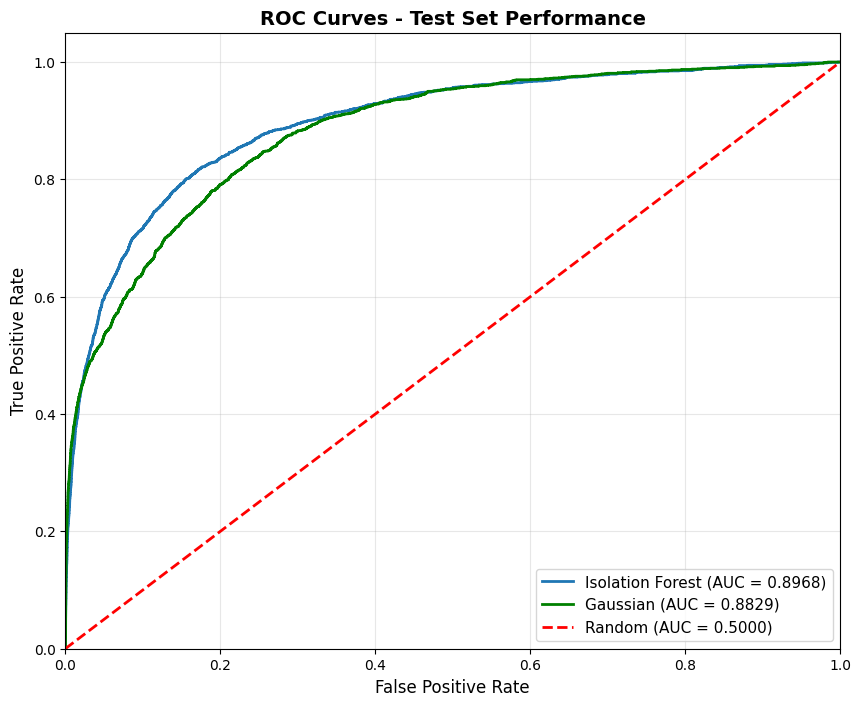

In [165]:
# Cell 14: Plot ROC Curves
plt.figure(figsize=(10, 8))

plt.plot(fpr_iso, tpr_iso, lw=2,
         label=f'Isolation Forest (AUC = {roc_auc_iso:.4f})')

plt.plot(fpr_gaussian, tpr_gaussian, color='green', lw=2,
         label=f'Gaussian (AUC = {roc_auc_gaussian:.4f})')

plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--',
         label='Random (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Test Set Performance', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()
